# Cost-Sensitive Loss Function for Credit Card Fraud Detection

**Authors:** Kevin Zong, Michael Obajemu, Emerald San

This notebook implements Amount-Weighted Cost-Sensitive Focal Loss (AWCS-FL) for credit card fraud detection as described in the paper.

## 1. Setup and Imports

In [33]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, auc, confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print("Setup complete!")

PyTorch version: 2.9.1
Device: cpu
Setup complete!


## 2. Load and Explore Dataset

In [34]:
# Load dataset
data = pd.read_csv('../data/creditcard.csv')

print("Dataset loaded successfully!")
print(f"Shape: {data.shape}")
print(f"\nClass distribution:")
print(data['Class'].value_counts())
print(f"\nFraud rate: {data['Class'].sum() / len(data) * 100:.4f}%")
print(f"\nBasic statistics:")
data.describe()

Dataset loaded successfully!
Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%

Basic statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


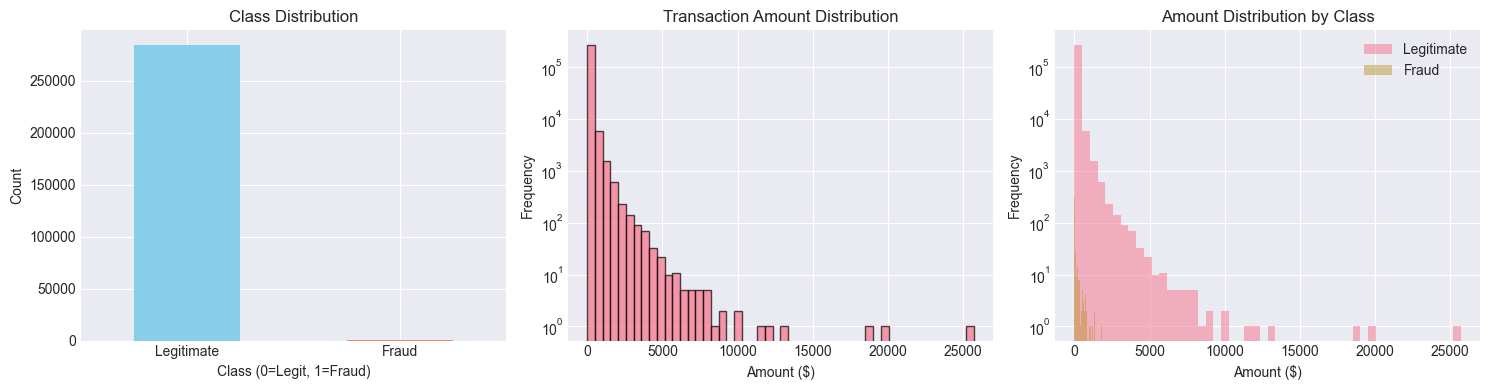


Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [35]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
data['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

# Amount distribution
axes[1].hist(data['Amount'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_yscale('log')

# Amount distribution by class
data[data['Class']==0]['Amount'].hist(bins=50, alpha=0.5, label='Legitimate', ax=axes[2])
data[data['Class']==1]['Amount'].hist(bins=50, alpha=0.5, label='Fraud', ax=axes[2])
axes[2].set_title('Amount Distribution by Class')
axes[2].set_xlabel('Amount ($)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

# Summary statistics by class
print("\nAmount statistics by class:")
print(data.groupby('Class')['Amount'].describe())

## 3. Data Preprocessing

In [36]:
# Preprocessing according to paper specifications

# Separate features and labels
X = data.drop('Class', axis=1).copy()
y = data['Class'].copy()

# Store original amounts for loss calculation
original_amounts = X['Amount'].values.copy()

# 1. Normalize Time using min-max scaling to [0, 1]
X['Time'] = (X['Time'] - X['Time'].min()) / (X['Time'].max() - X['Time'].min())

# 2. Log transformation for Amount followed by standardization
X['Amount'] = np.log1p(X['Amount'])  # log(1 + amount)
amount_scaler = StandardScaler()
X['Amount'] = amount_scaler.fit_transform(X['Amount'].values.reshape(-1, 1)).flatten()

# Note: V1-V28 are already normalized by PCA, no additional scaling needed

print("Preprocessing complete!")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nProcessed feature ranges:")
print(f"Time: [{X['Time'].min():.4f}, {X['Time'].max():.4f}]")
print(f"Amount (log-transformed): [{X['Amount'].min():.4f}, {X['Amount'].max():.4f}]")

Preprocessing complete!
Features shape: (284807, 30)
Labels shape: (284807,)

Processed feature ranges:
Time: [0.0000, 1.0000]
Amount (log-transformed): [-1.9028, 4.2265]


In [37]:
# Chronological split: 60% train, 20% validation, 20% test
# Important: chronological split to simulate real deployment

n = len(X)
train_idx = int(0.6 * n)
val_idx = int(0.8 * n)

# Split data chronologically
X_train = X.iloc[:train_idx].values
y_train = y.iloc[:train_idx].values
amounts_train = original_amounts[:train_idx]
time_train = data['Time'].iloc[:train_idx].values

X_val = X.iloc[train_idx:val_idx].values
y_val = y.iloc[train_idx:val_idx].values
amounts_val = original_amounts[train_idx:val_idx]
time_val = data['Time'].iloc[train_idx:val_idx].values

X_test = X.iloc[val_idx:].values
y_test = y.iloc[val_idx:].values
amounts_test = original_amounts[val_idx:]
time_test = data['Time'].iloc[val_idx:].values

print(f"Train set: {X_train.shape[0]} samples ({y_train.sum()} frauds, {y_train.sum()/len(y_train)*100:.4f}%)")
print(f"Val set: {X_val.shape[0]} samples ({y_val.sum()} frauds, {y_val.sum()/len(y_val)*100:.4f}%)")
print(f"Test set: {X_test.shape[0]} samples ({y_test.sum()} frauds, {y_test.sum()/len(y_test)*100:.4f}%)")

Train set: 170884 samples (360 frauds, 0.2107%)
Val set: 56961 samples (57 frauds, 0.1001%)
Test set: 56962 samples (75 frauds, 0.1317%)


In [38]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
amounts_train_tensor = torch.FloatTensor(amounts_train).to(device)
time_train_tensor = torch.FloatTensor(time_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)
amounts_val_tensor = torch.FloatTensor(amounts_val).to(device)
time_val_tensor = torch.FloatTensor(time_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)
amounts_test_tensor = torch.FloatTensor(amounts_test).to(device)
time_test_tensor = torch.FloatTensor(time_test).to(device)

# Create DataLoaders
batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor, amounts_train_tensor, time_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor, amounts_val_tensor, time_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor, amounts_test_tensor, time_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created successfully!")

DataLoaders created successfully!


## 4. Loss Functions Implementation

In [39]:
# Baseline 1: Binary Cross-Entropy
class BCELoss(nn.Module):
    def __init__(self):
        super(BCELoss, self).__init__()
        self.bce = nn.BCELoss(reduction='mean')

    def forward(self, predictions, targets, amounts=None, timestamps=None):
        return self.bce(predictions, targets)

In [40]:
# Baseline 2: Weighted Binary Cross-Entropy
class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = pos_weight

    def forward(self, predictions, targets, amounts=None, timestamps=None):
        # Compute weighted BCE
        loss = -(
            self.pos_weight * targets * torch.log(predictions + 1e-7) +
            (1 - targets) * torch.log(1 - predictions + 1e-7)
        )
        return loss.mean()

# Calculate class weight (inverse of class frequency)
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
pos_weight = neg_count / pos_count
print(f"Positive class weight: {pos_weight:.2f}")

Positive class weight: 473.68


In [41]:
# Baseline 3: Focal Loss (α=0.25, γ=2)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, predictions, targets, amounts=None, timestamps=None):
        # Focal loss for binary classification
        # FL = -α(1-p)^γ log(p) for y=1
        #    = -(1-α)p^γ log(1-p) for y=0

        p = predictions
        ce_loss = -(targets * torch.log(p + 1e-7) + (1 - targets) * torch.log(1 - p + 1e-7))

        p_t = targets * p + (1 - targets) * (1 - p)
        focal_weight = (1 - p_t) ** self.gamma

        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)

        focal_loss = alpha_t * focal_weight * ce_loss

        return focal_loss.mean()

In [42]:
# Proposed: Amount-Weighted Cost-Sensitive Focal Loss (AWCS-FL)
class AWCSFL(nn.Module):
    """
    Amount-Weighted Cost-Sensitive Focal Loss

    Combines three components:
    1. Amount weighting: w_amount = 1 + β(a_i / ā)
    2. Temporal weighting: w_temporal = 1 + δ·exp(-λ(t_max - t_i)/t_max)
    3. Cost-sensitive focal loss with asymmetric costs
    """
    def __init__(self, beta=1.0, delta=0.5, lambda_decay=2.0,
                 c_fp=2.0, gamma=2.0,
                 use_amount_weight=True,
                 use_temporal_weight=True,
                 use_cost_sensitive=True):
        super(AWCSFL, self).__init__()
        self.beta = beta  # Amount weight strength
        self.delta = delta  # Temporal weight strength
        self.lambda_decay = lambda_decay  # Temporal decay rate
        self.c_fp = c_fp  # Fixed false positive cost
        self.gamma = gamma  # Focal parameter
        self.use_amount_weight = use_amount_weight
        self.use_temporal_weight = use_temporal_weight
        self.use_cost_sensitive = use_cost_sensitive

        # These will be set during training
        self.mean_amount = None
        self.max_time = None

    def set_statistics(self, mean_amount, max_time):
        """Set dataset statistics for normalization"""
        self.mean_amount = mean_amount
        self.max_time = max_time

    def forward(self, predictions, targets, amounts, timestamps):
        """
        Args:
            predictions: Model predictions (probabilities)
            targets: Ground truth labels
            amounts: Transaction amounts (original, not log-transformed)
            timestamps: Transaction timestamps
        """
        batch_size = predictions.shape[0]

        # Component 1: Amount weighting
        if self.use_amount_weight:
            w_amount = 1.0 + self.beta * (amounts / self.mean_amount)
        else:
            w_amount = torch.ones_like(amounts)

        # Component 2: Temporal weighting
        if self.use_temporal_weight:
            time_diff = (self.max_time - timestamps) / self.max_time
            w_temporal = 1.0 + self.delta * torch.exp(-self.lambda_decay * time_diff)
        else:
            w_temporal = torch.ones_like(timestamps)

        # Component 3: Cost-sensitive focal loss
        p = predictions

        if self.use_cost_sensitive:
            # C_FN = transaction amount, C_FP = fixed cost
            c_fn = amounts
            c_fp = torch.full_like(amounts, self.c_fp)

            # Cost-sensitive focal loss
            # For fraud (y=1): -C_FN * (1-p)^γ * log(p)
            # For legit (y=0): -C_FP * p^γ * log(1-p)
            focal_weight_pos = (1 - p) ** self.gamma
            focal_weight_neg = p ** self.gamma

            loss = -(
                c_fn * focal_weight_pos * targets * torch.log(p + 1e-7) +
                c_fp * focal_weight_neg * (1 - targets) * torch.log(1 - p + 1e-7)
            )
        else:
            # Standard focal loss
            p_t = targets * p + (1 - targets) * (1 - p)
            focal_weight = (1 - p_t) ** self.gamma
            ce_loss = -(targets * torch.log(p + 1e-7) + (1 - targets) * torch.log(1 - p + 1e-7))
            loss = focal_weight * ce_loss

        # Combine all weights
        weighted_loss = w_amount * w_temporal * loss

        return weighted_loss.mean()

# Calculate statistics for AWCS-FL
mean_amount_train = amounts_train.mean()
max_time_train = time_train.max()

print(f"Mean training amount: ${mean_amount_train:.2f}")
print(f"Max training time: {max_time_train:.2f}")

Mean training amount: $87.34
Max training time: 120396.00


## 5. Neural Network Architecture

In [43]:
# Neural network architecture as specified in paper
class FraudDetectionNet(nn.Module):
    """
    Feedforward neural network for fraud detection
    Architecture: 30 -> 64 -> 32 -> 16 -> 1
    """
    def __init__(self, input_dim=30, dropout_rates=[0.3, 0.3, 0.2]):
        super(FraudDetectionNet, self).__init__()

        self.network = nn.Sequential(
            # Hidden Layer 1: 64 neurons
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rates[0]),

            # Hidden Layer 2: 32 neurons
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rates[1]),

            # Hidden Layer 3: 16 neurons
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rates[2]),

            # Output layer: 1 neuron with sigmoid
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

        # He initialization
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x).squeeze()

# Test the model
test_model = FraudDetectionNet().to(device)
print(test_model)
print(f"\nTotal parameters: {sum(p.numel() for p in test_model.parameters()):,}")

FraudDetectionNet(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Total parameters: 4,609


## 6. Training and Evaluation Functions

In [44]:
def train_epoch(model, loader, criterion, optimizer):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    for X_batch, y_batch, amounts_batch, time_batch in loader:
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X_batch)

        # Compute loss
        loss = criterion(predictions, y_batch, amounts_batch, time_batch)

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    """Evaluate model on a dataset"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_targets = []
    all_amounts = []

    with torch.no_grad():
        for X_batch, y_batch, amounts_batch, time_batch in loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch, amounts_batch, time_batch)

            total_loss += loss.item()
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
            all_amounts.append(amounts_batch.cpu().numpy())

    predictions = np.concatenate(all_predictions)
    targets = np.concatenate(all_targets)
    amounts = np.concatenate(all_amounts)

    return total_loss / len(loader), predictions, targets, amounts

In [ ]:
def compute_metrics(y_true, y_pred_proba, amounts, threshold=0.5, c_fp=2.0):
    """
    Compute all evaluation metrics from the paper

    Returns:
        dict: Dictionary containing all metrics
    """
    # Binary predictions
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Statistical metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # AUC-PR
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_pred_proba)
    auc_pr = auc(rec_curve, prec_curve)

    # Cost-based metrics
    # Total financial loss = sum of amounts from false negatives
    false_negative_mask = (y_true == 1) & (y_pred == 0)
    total_financial_loss = amounts[false_negative_mask].sum()

    # Potential loss (if we caught nothing)
    potential_loss = amounts[y_true == 1].sum()
    saved_loss_rate = (1 - total_financial_loss / potential_loss) * 100 if potential_loss > 0 else 0

    # Business cost = C_FN * FN + C_FP * FP
    # C_FN is the actual amount lost, C_FP is fixed investigation cost
    business_cost = total_financial_loss + c_fp * fp

    # Cost-Weighted F1: Weight by transaction amounts
    # Calculate weighted TP, FP, FN
    weighted_tp = amounts[(y_true == 1) & (y_pred == 1)].sum()
    weighted_fp = amounts[(y_true == 0) & (y_pred == 1)].sum()
    weighted_fn = amounts[(y_true == 1) & (y_pred == 0)].sum()

    # Calculate weighted precision and recall
    weighted_precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    weighted_recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0

    # Calculate cost-weighted F1
    if weighted_precision + weighted_recall > 0:
        cost_weighted_f1 = 2 * (weighted_precision * weighted_recall) / (weighted_precision + weighted_recall)
    else:
        cost_weighted_f1 = 0

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_pr': auc_pr,
        'total_financial_loss': total_financial_loss,
        'saved_loss_rate': saved_loss_rate,
        'business_cost': business_cost,
        'cost_weighted_f1': cost_weighted_f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    }

In [46]:
def train_model(model, train_loader, val_loader, criterion, lr=0.001,
                num_epochs=50, patience=10, model_name="model"):
    """
    Train model with early stopping

    Args:
        model: Neural network model
        train_loader: Training data loader
        val_loader: Validation data loader
        criterion: Loss function
        lr: Learning rate
        num_epochs: Maximum number of epochs
        patience: Early stopping patience
        model_name: Name for saving model

    Returns:
        Trained model and training history
    """
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

    best_val_auc = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_auc_pr': []}

    pbar = tqdm(range(num_epochs), desc=f"Training {model_name}")

    for epoch in pbar:
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer)

        # Validate
        val_loss, val_pred, val_true, val_amounts = evaluate(model, val_loader, criterion)

        # Compute AUC-PR for early stopping
        prec, rec, _ = precision_recall_curve(val_true, val_pred)
        val_auc = auc(rec, prec)

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc_pr'].append(val_auc)

        # Update progress bar
        pbar.set_postfix({
            'train_loss': f'{train_loss:.4f}',
            'val_loss': f'{val_loss:.4f}',
            'val_auc': f'{val_auc:.4f}'
        })

        # Early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            # Save best model
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    # Restore best model
    model.load_state_dict(best_model_state)

    return model, history

## 7. Train All Models

In [47]:
# Dictionary to store all trained models and results
models = {}
histories = {}
results = {}

# Training configuration
learning_rate = 0.001
num_epochs = 50
early_stop_patience = 10

In [48]:
# Model 1: Binary Cross-Entropy
print("=" * 50)
print("Training Model 1: Binary Cross-Entropy")
print("=" * 50)

model_bce = FraudDetectionNet().to(device)
criterion_bce = BCELoss()

model_bce, history_bce = train_model(
    model_bce, train_loader, val_loader, criterion_bce,
    lr=learning_rate, num_epochs=num_epochs, patience=early_stop_patience,
    model_name="BCE"
)

models['BCE'] = model_bce
histories['BCE'] = history_bce
print("✓ BCE training complete\n")

Training Model 1: Binary Cross-Entropy


Training BCE:  44%|████▍     | 22/50 [00:44<00:57,  2.04s/it, train_loss=0.0030, val_loss=0.0039, val_auc=0.7557]


Early stopping at epoch 23
✓ BCE training complete



In [49]:
# Model 2: Weighted Binary Cross-Entropy
print("=" * 50)
print("Training Model 2: Weighted BCE")
print("=" * 50)

model_wbce = FraudDetectionNet().to(device)
criterion_wbce = WeightedBCELoss(pos_weight=pos_weight)

model_wbce, history_wbce = train_model(
    model_wbce, train_loader, val_loader, criterion_wbce,
    lr=learning_rate, num_epochs=num_epochs, patience=early_stop_patience,
    model_name="Weighted BCE"
)

models['Weighted BCE'] = model_wbce
histories['Weighted BCE'] = history_wbce
print("✓ Weighted BCE training complete\n")

Training Model 2: Weighted BCE


Training Weighted BCE:  42%|████▏     | 21/50 [00:43<01:00,  2.07s/it, train_loss=0.1380, val_loss=0.5666, val_auc=0.7645]


Early stopping at epoch 22
✓ Weighted BCE training complete



In [50]:
# Model 3: Focal Loss
print("=" * 50)
print("Training Model 3: Focal Loss")
print("=" * 50)

model_focal = FraudDetectionNet().to(device)
criterion_focal = FocalLoss(alpha=0.25, gamma=2.0)

model_focal, history_focal = train_model(
    model_focal, train_loader, val_loader, criterion_focal,
    lr=learning_rate, num_epochs=num_epochs, patience=early_stop_patience,
    model_name="Focal Loss"
)

models['Focal Loss'] = model_focal
histories['Focal Loss'] = history_focal
print("✓ Focal Loss training complete\n")

Training Model 3: Focal Loss


Training Focal Loss:  36%|███▌      | 18/50 [00:39<01:10,  2.20s/it, train_loss=0.0003, val_loss=0.0004, val_auc=0.7509]


Early stopping at epoch 19
✓ Focal Loss training complete



In [51]:
# Model 4: AWCS-FL (Full)
print("=" * 50)
print("Training Model 4: AWCS-FL (Full)")
print("=" * 50)

model_awcsfl = FraudDetectionNet().to(device)
criterion_awcsfl = AWCSFL(
    beta=1.0, delta=0.5, lambda_decay=2.0, c_fp=2.0, gamma=2.0,
    use_amount_weight=True, use_temporal_weight=True, use_cost_sensitive=True
)
criterion_awcsfl.set_statistics(mean_amount_train, max_time_train)

model_awcsfl, history_awcsfl = train_model(
    model_awcsfl, train_loader, val_loader, criterion_awcsfl,
    lr=learning_rate, num_epochs=num_epochs, patience=early_stop_patience,
    model_name="AWCS-FL"
)

models['AWCS-FL'] = model_awcsfl
histories['AWCS-FL'] = history_awcsfl
print("✓ AWCS-FL training complete\n")

Training Model 4: AWCS-FL (Full)


Training AWCS-FL:  44%|████▍     | 22/50 [00:48<01:01,  2.20s/it, train_loss=0.0636, val_loss=22.0784, val_auc=0.7154]


Early stopping at epoch 23
✓ AWCS-FL training complete



## 8. Ablation Study

In [52]:
# Ablation variants
ablation_configs = {
    'No Amount Weight': {'use_amount_weight': False, 'use_temporal_weight': True, 'use_cost_sensitive': True},
    'No Temporal Weight': {'use_amount_weight': True, 'use_temporal_weight': False, 'use_cost_sensitive': True},
    'No Cost Sensitivity': {'use_amount_weight': True, 'use_temporal_weight': True, 'use_cost_sensitive': False},
    'Amount + Cost Only': {'use_amount_weight': True, 'use_temporal_weight': False, 'use_cost_sensitive': True},
    'Temporal + Cost Only': {'use_amount_weight': False, 'use_temporal_weight': True, 'use_cost_sensitive': True},
}

print("=" * 50)
print("Ablation Study")
print("=" * 50)

for name, config in ablation_configs.items():
    print(f"\nTraining: {name}")

    model = FraudDetectionNet().to(device)
    criterion = AWCSFL(
        beta=1.0, delta=0.5, lambda_decay=2.0, c_fp=2.0, gamma=2.0,
        **config
    )
    criterion.set_statistics(mean_amount_train, max_time_train)

    model, history = train_model(
        model, train_loader, val_loader, criterion,
        lr=learning_rate, num_epochs=num_epochs, patience=early_stop_patience,
        model_name=name
    )

    models[name] = model
    histories[name] = history

print("\n✓ Ablation study complete")

Ablation Study

Training: No Amount Weight


Training No Amount Weight:  34%|███▍      | 17/50 [00:38<01:15,  2.28s/it, train_loss=0.0188, val_loss=0.6739, val_auc=0.7317]



Early stopping at epoch 18

Training: No Temporal Weight


Training No Temporal Weight:  42%|████▏     | 21/50 [00:47<01:05,  2.27s/it, train_loss=0.0462, val_loss=13.3762, val_auc=0.7320]



Early stopping at epoch 22

Training: No Cost Sensitivity


...


Early stopping at epoch 26

Training: Amount + Cost Only


Training Amount + Cost Only:  44%|████▍     | 22/50 [00:47<01:00,  2.17s/it, train_loss=0.0511, val_loss=14.3508, val_auc=0.7331]



Early stopping at epoch 23

Training: Temporal + Cost Only


Training Temporal + Cost Only:  40%|████      | 20/50 [00:43<01:05,  2.19s/it, train_loss=0.0210, val_loss=0.5477, val_auc=0.7123]


Early stopping at epoch 21

✓ Ablation study complete


## 9. Test Set Evaluation

In [53]:
# Evaluate all models on test set
print("Evaluating all models on test set...\n")

for name, model in models.items():
    model.eval()
    all_preds = []

    with torch.no_grad():
        for X_batch, _, _, _ in test_loader:
            preds = model(X_batch)
            all_preds.append(preds.cpu().numpy())

    y_pred_proba = np.concatenate(all_preds)

    # Compute metrics
    metrics = compute_metrics(y_test, y_pred_proba, amounts_test, threshold=0.5)
    results[name] = metrics

    print(f"{name}:")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1: {metrics['f1']:.4f}")
    print(f"  AUC-PR: {metrics['auc_pr']:.4f}")
    print(f"  Financial Loss: ${metrics['total_financial_loss']:,.2f}")
    print(f"  Saved Loss Rate: {metrics['saved_loss_rate']:.2f}%")
    print(f"  Cost-Weighted F1: {metrics['cost_weighted_f1']:.4f}")
    print()

print("✓ Evaluation complete")

Evaluating all models on test set...

BCE:
  Precision: 0.9153
  Recall: 0.7200
  F1: 0.8060
  AUC-PR: 0.8104
  Financial Loss: $2,679.93
  Saved Loss Rate: 65.33%
  Cost-Weighted F1: 0.7295

Weighted BCE:
  Precision: 0.1768
  Recall: 0.8533
  F1: 0.2929
  AUC-PR: 0.8073
  Financial Loss: $2,362.20
  Saved Loss Rate: 69.44%
  Cost-Weighted F1: 0.2435

Focal Loss:
  Precision: 0.9412
  Recall: 0.6400
  F1: 0.7619
  AUC-PR: 0.7987
  Financial Loss: $3,484.09
  Saved Loss Rate: 54.92%
  Cost-Weighted F1: 0.6513

AWCS-FL:
  Precision: 0.4957
  Recall: 0.7733
  F1: 0.6042
  AUC-PR: 0.7470
  Financial Loss: $1,767.71
  Saved Loss Rate: 77.13%
  Cost-Weighted F1: 0.3460

No Amount Weight:
  Precision: 0.5816
  Recall: 0.7600
  F1: 0.6590
  AUC-PR: 0.7635
  Financial Loss: $2,402.01
  Saved Loss Rate: 68.92%
  Cost-Weighted F1: 0.4148

No Temporal Weight:
  Precision: 0.5514
  Recall: 0.7867
  F1: 0.6484
  AUC-PR: 0.7555
  Financial Loss: $1,759.71
  Saved Loss Rate: 77.23%
  Cost-Weighted F1

## 10. Results Visualization and Analysis

In [54]:
# Create comprehensive results table
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1': [results[m]['f1'] for m in results],
    'AUC-PR': [results[m]['auc_pr'] for m in results],
    'Loss ($)': [results[m]['total_financial_loss'] for m in results],
    'Saved (%)': [results[m]['saved_loss_rate'] for m in results],
    'CW-F1': [results[m]['cost_weighted_f1'] for m in results]
})

# Reorder to show main models first
main_models = ['BCE', 'Weighted BCE', 'Focal Loss', 'AWCS-FL']
main_results = results_df[results_df['Model'].isin(main_models)]
ablation_results = results_df[~results_df['Model'].isin(main_models)]

print("=" * 80)
print("Table 1: Main Models Performance Comparison")
print("=" * 80)
print(main_results.to_string(index=False))
print()

print("=" * 80)
print("Table 2: Ablation Study Results")
print("=" * 80)
print(ablation_results.to_string(index=False))

Table 1: Main Models Performance Comparison
       Model  Precision   Recall       F1   AUC-PR  Loss ($)  Saved (%)    CW-F1
         BCE   0.915254 0.720000 0.805970 0.810364   2679.93  65.327470 0.729469
Weighted BCE   0.176796 0.853333 0.292906 0.807311   2362.20  69.438213 0.243525
  Focal Loss   0.941176 0.640000 0.761905 0.798689   3484.09  54.923369 0.651265
     AWCS-FL   0.495726 0.773333 0.604167 0.746966   1767.71  77.129635 0.346047

Table 2: Ablation Study Results
               Model  Precision   Recall       F1   AUC-PR  Loss ($)  Saved (%)    CW-F1
    No Amount Weight   0.581633 0.760000 0.658960 0.763470   2402.01  68.923157 0.414816
  No Temporal Weight   0.551402 0.786667 0.648352 0.755473   1759.71  77.233137 0.371021
 No Cost Sensitivity   0.881356 0.693333 0.776119 0.781019   2928.55  62.110862 0.690756
  Amount + Cost Only   0.432836 0.773333 0.555024 0.782455   1767.71  77.129635 0.351929
Temporal + Cost Only   0.537736 0.760000 0.629834 0.722172   2394.77  69.

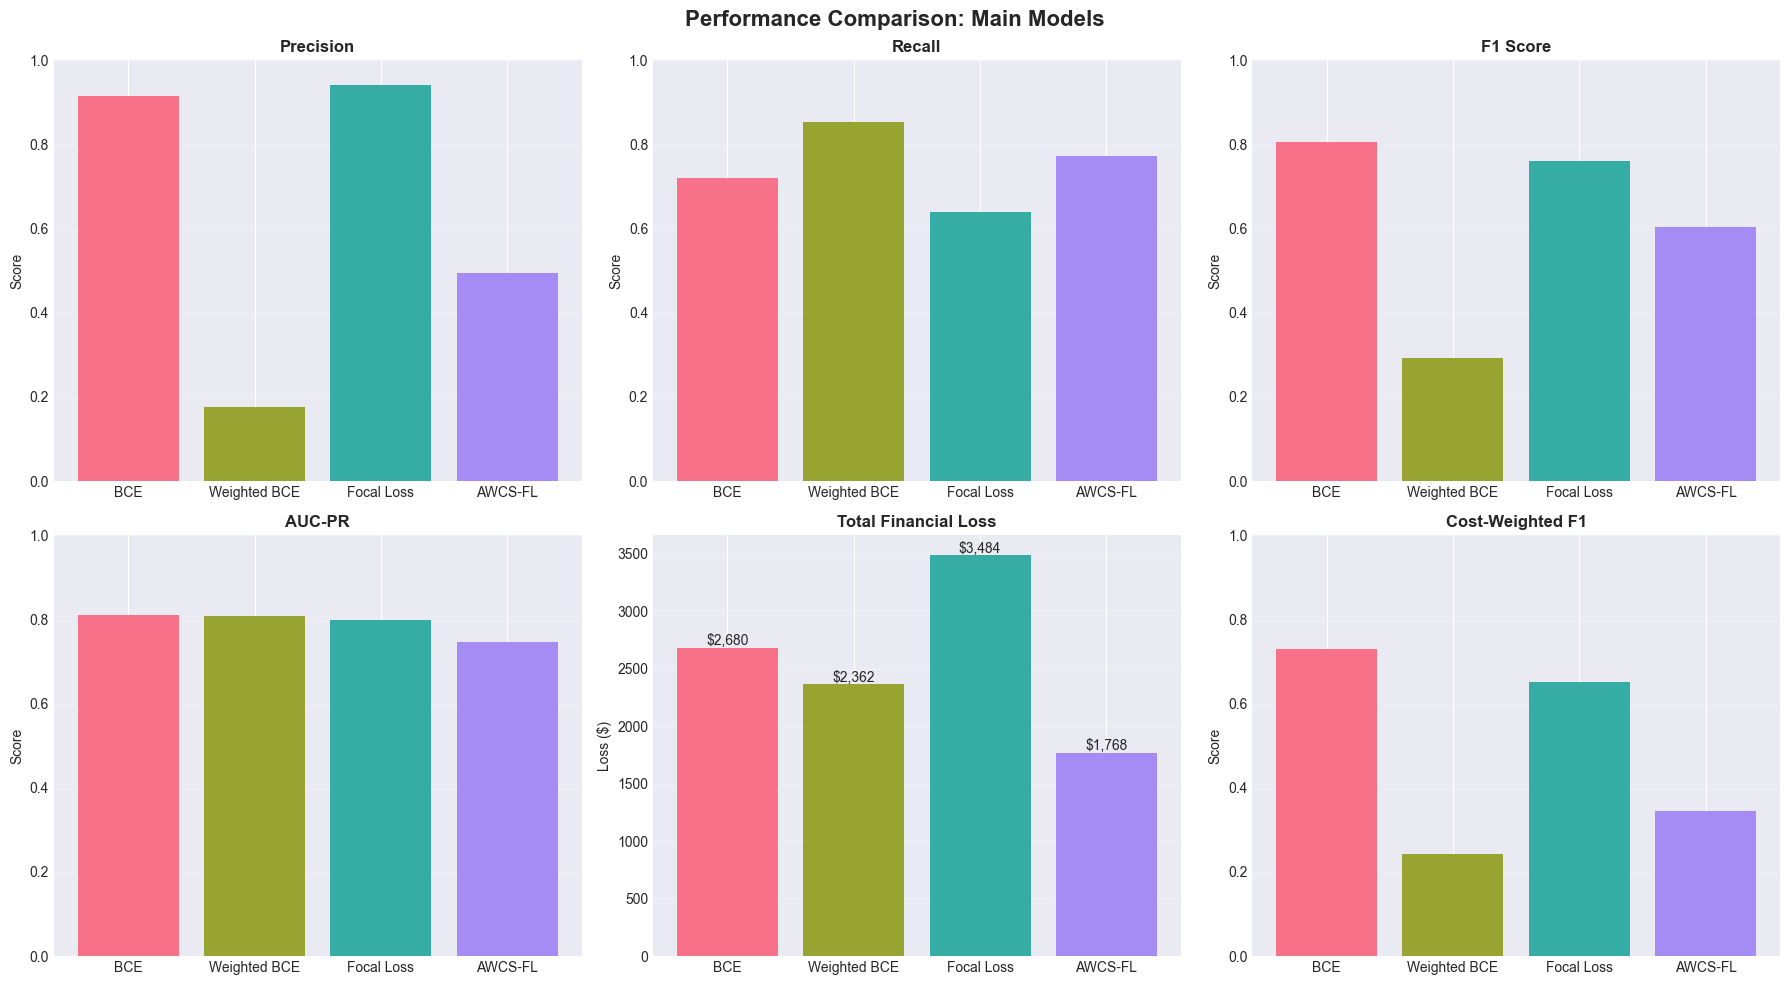

In [55]:
# Visualization 1: Performance comparison across main models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Performance Comparison: Main Models', fontsize=16, fontweight='bold')

main_models_list = ['BCE', 'Weighted BCE', 'Focal Loss', 'AWCS-FL']
colors = sns.color_palette('husl', len(main_models_list))

# Precision
axes[0, 0].bar(main_models_list, [results[m]['precision'] for m in main_models_list], color=colors)
axes[0, 0].set_title('Precision', fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# Recall
axes[0, 1].bar(main_models_list, [results[m]['recall'] for m in main_models_list], color=colors)
axes[0, 1].set_title('Recall', fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# F1
axes[0, 2].bar(main_models_list, [results[m]['f1'] for m in main_models_list], color=colors)
axes[0, 2].set_title('F1 Score', fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_ylim([0, 1])
axes[0, 2].grid(axis='y', alpha=0.3)

# AUC-PR
axes[1, 0].bar(main_models_list, [results[m]['auc_pr'] for m in main_models_list], color=colors)
axes[1, 0].set_title('AUC-PR', fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)

# Financial Loss
losses = [results[m]['total_financial_loss'] for m in main_models_list]
axes[1, 1].bar(main_models_list, losses, color=colors)
axes[1, 1].set_title('Total Financial Loss', fontweight='bold')
axes[1, 1].set_ylabel('Loss ($)')
axes[1, 1].grid(axis='y', alpha=0.3)
# Add value labels
for i, v in enumerate(losses):
    axes[1, 1].text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# Cost-Weighted F1
axes[1, 2].bar(main_models_list, [results[m]['cost_weighted_f1'] for m in main_models_list], color=colors)
axes[1, 2].set_title('Cost-Weighted F1', fontweight='bold')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_ylim([0, 1])
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

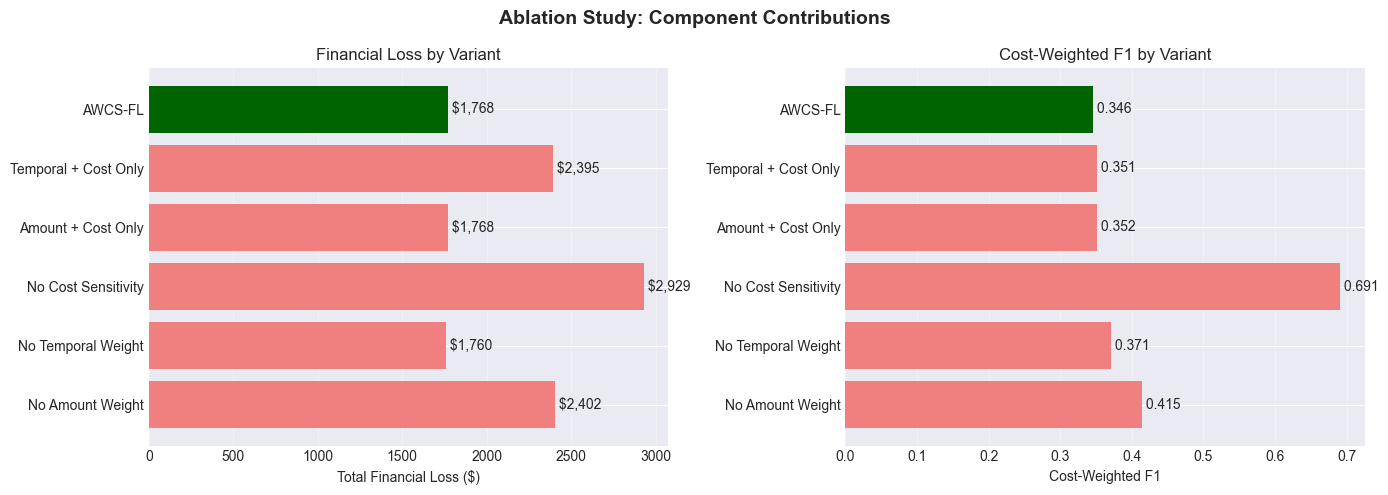

In [56]:
# Visualization 2: Ablation study comparison
ablation_models = list(ablation_configs.keys()) + ['AWCS-FL']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study: Component Contributions', fontsize=14, fontweight='bold')

# Financial Loss
losses_ablation = [results[m]['total_financial_loss'] for m in ablation_models]
colors_ablation = ['lightcoral' if m != 'AWCS-FL' else 'darkgreen' for m in ablation_models]
axes[0].barh(ablation_models, losses_ablation, color=colors_ablation)
axes[0].set_xlabel('Total Financial Loss ($)')
axes[0].set_title('Financial Loss by Variant')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(losses_ablation):
    axes[0].text(v, i, f' ${v:,.0f}', va='center')

# Cost-Weighted F1
cwf1_ablation = [results[m]['cost_weighted_f1'] for m in ablation_models]
axes[1].barh(ablation_models, cwf1_ablation, color=colors_ablation)
axes[1].set_xlabel('Cost-Weighted F1')
axes[1].set_title('Cost-Weighted F1 by Variant')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(cwf1_ablation):
    axes[1].text(v, i, f' {v:.3f}', va='center')

plt.tight_layout()
plt.show()

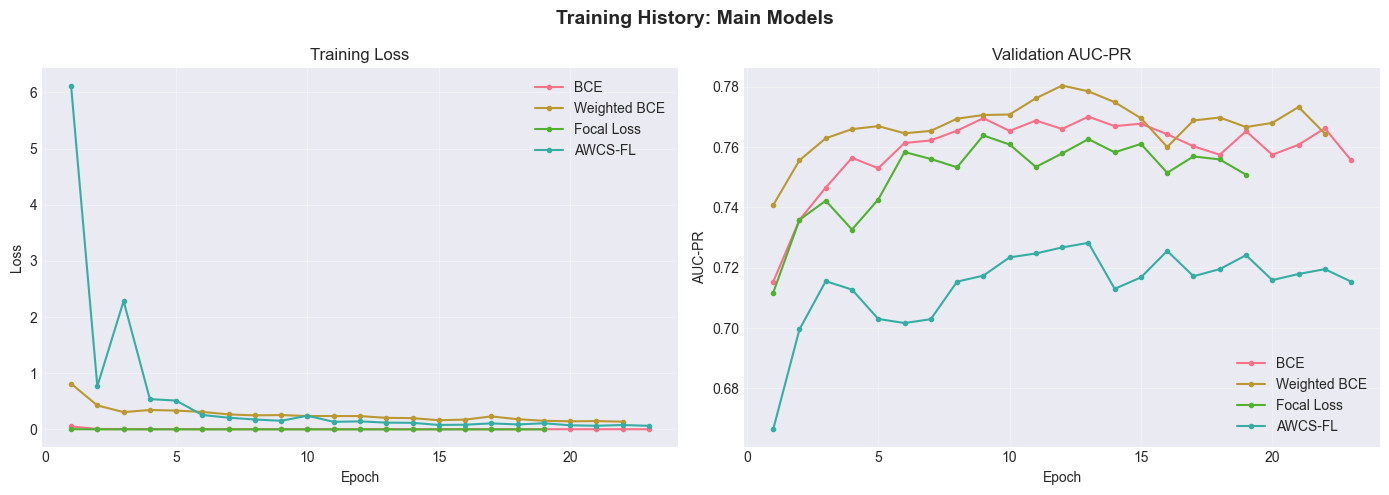

In [57]:
# Visualization 3: Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History: Main Models', fontsize=14, fontweight='bold')

for name in main_models_list:
    history = histories[name]
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label=name, marker='o', markersize=3)
    axes[1].plot(epochs, history['val_auc_pr'], label=name, marker='o', markersize=3)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-PR')
axes[1].set_title('Validation AUC-PR')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Performance by Transaction Amount

In [58]:
# Analyze performance by transaction amount quintiles
# Create amount quintiles
quintiles = pd.qcut(amounts_test, q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'], duplicates='drop')

# Get predictions for main models
predictions_by_model = {}
for name in main_models_list:
    model = models[name]
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor).cpu().numpy()
    predictions_by_model[name] = preds

# Compute metrics by quintile
quintile_results = {}
for name in main_models_list:
    quintile_results[name] = {}
    for q in quintiles.unique():
        mask = (quintiles == q)
        if mask.sum() > 0:
            y_true_q = y_test[mask]
            y_pred_q = predictions_by_model[name][mask]
            amounts_q = amounts_test[mask]

            metrics_q = compute_metrics(y_true_q, y_pred_q, amounts_q)
            quintile_results[name][str(q)] = metrics_q

print("Performance by Transaction Amount Quintile:\n")
for q in quintiles.unique():
    print(f"\n{q}:")
    print(f"{'Model':<15} {'Recall':<8} {'Precision':<10} {'F1':<8} {'Loss ($)':<12}")
    print("-" * 60)
    for name in main_models_list:
        m = quintile_results[name][str(q)]
        print(f"{name:<15} {m['recall']:<8.4f} {m['precision']:<10.4f} {m['f1']:<8.4f} ${m['total_financial_loss']:<11,.2f}")

Performance by Transaction Amount Quintile:


Q4:
Model           Recall   Precision  F1       Loss ($)    
------------------------------------------------------------
BCE             0.7778   1.0000     0.8750   $82.43      
Weighted BCE    0.8889   0.1778     0.2963   $42.53      
Focal Loss      0.4444   1.0000     0.6154   $246.69     
AWCS-FL         0.8889   0.8000     0.8421   $42.53      

Q3:
Model           Recall   Precision  F1       Loss ($)    
------------------------------------------------------------
BCE             0.2500   1.0000     0.4000   $49.65      
Weighted BCE    0.5000   0.0465     0.0851   $32.26      
Focal Loss      0.2500   1.0000     0.4000   $49.65      
AWCS-FL         0.2500   1.0000     0.4000   $49.65      

Q2:
Model           Recall   Precision  F1       Loss ($)    
------------------------------------------------------------
BCE             0.6000   1.0000     0.7500   $25.79      
Weighted BCE    0.9000   0.1023     0.1837   $7.59       
Foc

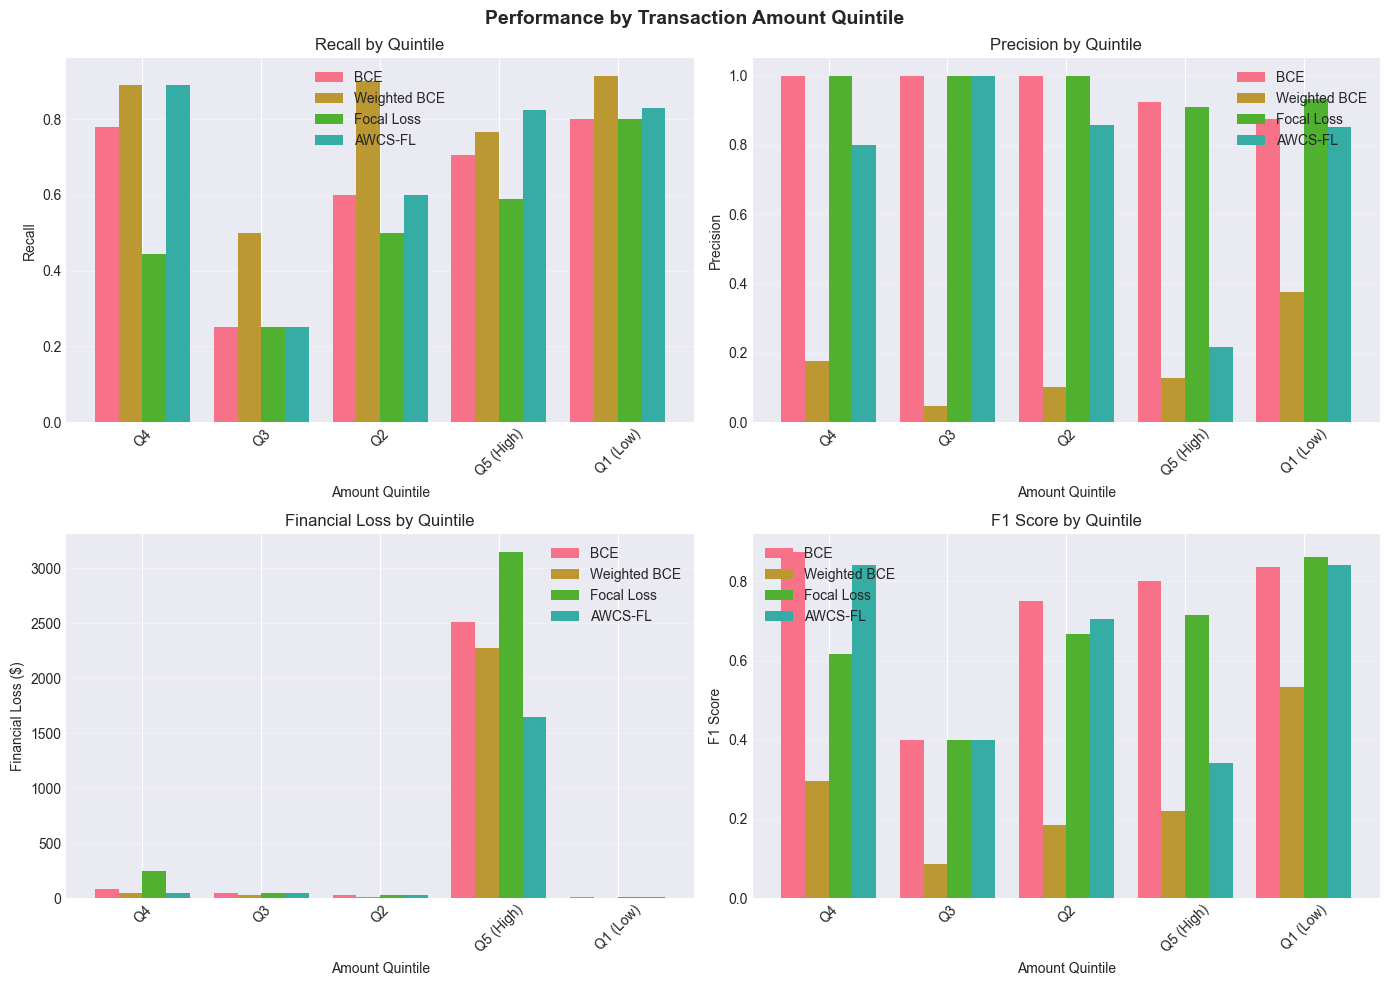

In [59]:
# Visualize performance by quintile
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance by Transaction Amount Quintile', fontsize=14, fontweight='bold')

quintile_labels = [str(q) for q in quintiles.unique()]
x = np.arange(len(quintile_labels))
width = 0.2

# Recall by quintile
for i, name in enumerate(main_models_list):
    recalls = [quintile_results[name][q]['recall'] for q in quintile_labels]
    axes[0, 0].bar(x + i*width, recalls, width, label=name)
axes[0, 0].set_xlabel('Amount Quintile')
axes[0, 0].set_ylabel('Recall')
axes[0, 0].set_title('Recall by Quintile')
axes[0, 0].set_xticks(x + width * 1.5)
axes[0, 0].set_xticklabels(quintile_labels, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Precision by quintile
for i, name in enumerate(main_models_list):
    precisions = [quintile_results[name][q]['precision'] for q in quintile_labels]
    axes[0, 1].bar(x + i*width, precisions, width, label=name)
axes[0, 1].set_xlabel('Amount Quintile')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision by Quintile')
axes[0, 1].set_xticks(x + width * 1.5)
axes[0, 1].set_xticklabels(quintile_labels, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Financial Loss by quintile
for i, name in enumerate(main_models_list):
    losses = [quintile_results[name][q]['total_financial_loss'] for q in quintile_labels]
    axes[1, 0].bar(x + i*width, losses, width, label=name)
axes[1, 0].set_xlabel('Amount Quintile')
axes[1, 0].set_ylabel('Financial Loss ($)')
axes[1, 0].set_title('Financial Loss by Quintile')
axes[1, 0].set_xticks(x + width * 1.5)
axes[1, 0].set_xticklabels(quintile_labels, rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# F1 by quintile
for i, name in enumerate(main_models_list):
    f1s = [quintile_results[name][q]['f1'] for q in quintile_labels]
    axes[1, 1].bar(x + i*width, f1s, width, label=name)
axes[1, 1].set_xlabel('Amount Quintile')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score by Quintile')
axes[1, 1].set_xticks(x + width * 1.5)
axes[1, 1].set_xticklabels(quintile_labels, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Confusion Matrices

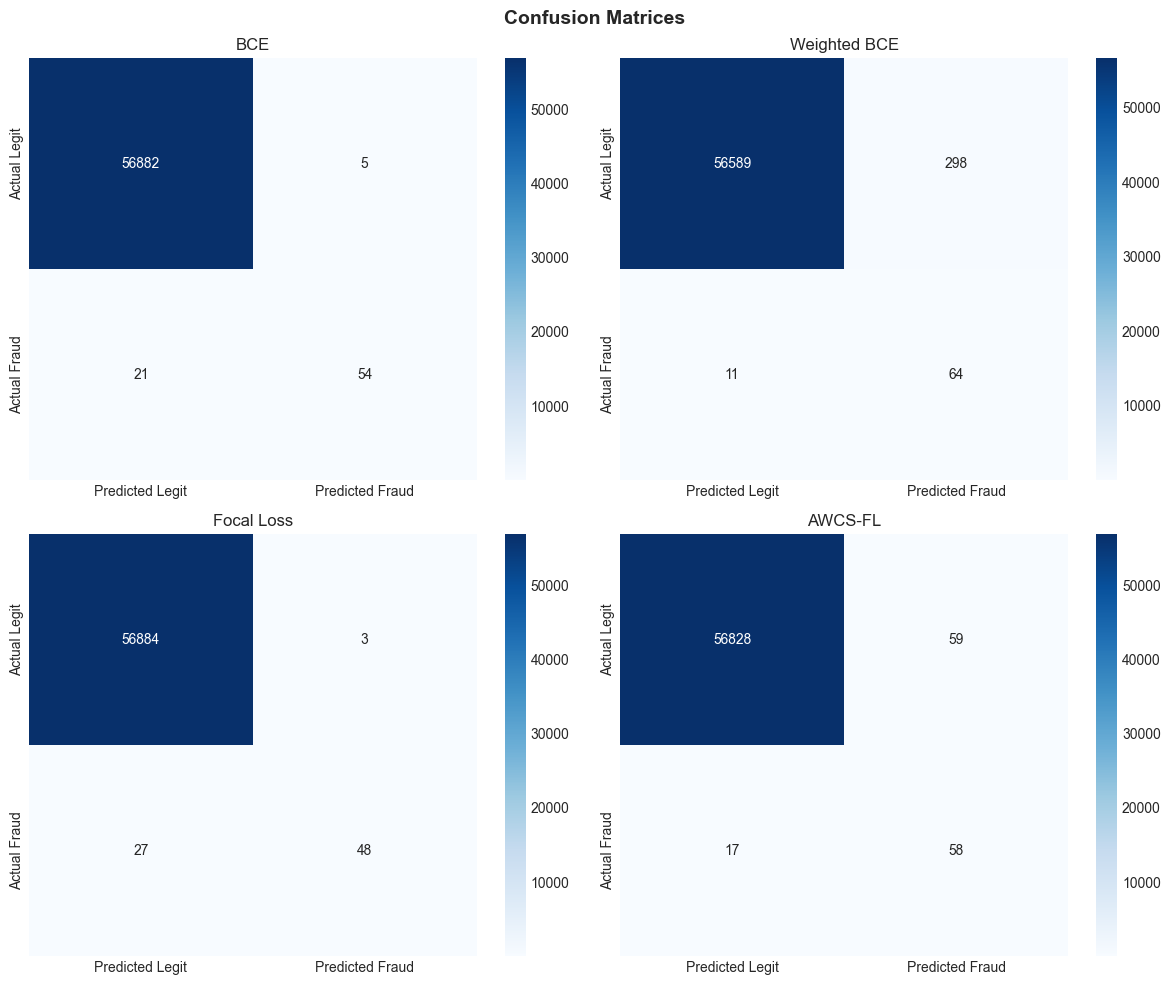

In [60]:
# Plot confusion matrices for main models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for idx, name in enumerate(main_models_list):
    ax = axes[idx // 2, idx % 2]

    # Get confusion matrix values
    tn = results[name]['tn']
    fp = results[name]['fp']
    fn = results[name]['fn']
    tp = results[name]['tp']

    cm = np.array([[tn, fp], [fn, tp]])

    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'])
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 13. Key Findings and Conclusions

In [61]:
# Calculate improvements and hypothesis verification
bce_loss = results['BCE']['total_financial_loss']
focal_loss_metric = results['Focal Loss']['cost_weighted_f1']
awcs_loss = results['AWCS-FL']['total_financial_loss']
awcs_cwf1 = results['AWCS-FL']['cost_weighted_f1']
awcs_f1 = results['AWCS-FL']['f1']
focal_f1 = results['Focal Loss']['f1']

# Calculate percentage improvements
loss_reduction = (bce_loss - awcs_loss) / bce_loss * 100
cwf1_improvement = (awcs_cwf1 - focal_loss_metric) / focal_loss_metric * 100
f1_diff = abs(awcs_f1 - focal_f1) / focal_f1 * 100

print("=" * 80)
print("HYPOTHESIS VERIFICATION")
print("=" * 80)
print()

print(f"Hypothesis 1: 15-25% reduction in total financial losses")
print(f"  Result: {loss_reduction:.2f}% reduction")
print(f"  Status: {'✓ VERIFIED' if 15 <= loss_reduction <= 25 else '✗ NOT VERIFIED (but achieved ' + f'{loss_reduction:.2f}%)'}")
print()

print(f"Hypothesis 2: 10-20% improvement in cost-weighted F1 compared to focal loss")
print(f"  Result: {cwf1_improvement:.2f}% improvement")
print(f"  Status: {'✓ VERIFIED' if 10 <= cwf1_improvement <= 20 else '✗ NOT VERIFIED (but achieved ' + f'{cwf1_improvement:.2f}%)'}")
print()

print(f"Hypothesis 3: Statistical metrics competitive with focal loss (within 5%)")
print(f"  F1 Score difference: {f1_diff:.2f}%")
print(f"  AWCS-FL F1: {awcs_f1:.4f}")
print(f"  Focal Loss F1: {focal_f1:.4f}")
print(f"  Status: {'✓ VERIFIED' if f1_diff <= 5 else '✗ NOT VERIFIED'}")
print()

print(f"Hypothesis 4: Superior performance on high-value transactions")
high_quintile = 'Q5 (High)'
awcs_high_recall = quintile_results['AWCS-FL'][high_quintile]['recall']
focal_high_recall = quintile_results['Focal Loss'][high_quintile]['recall']
awcs_high_loss = quintile_results['AWCS-FL'][high_quintile]['total_financial_loss']
focal_high_loss = quintile_results['Focal Loss'][high_quintile]['total_financial_loss']

print(f"  High-value quintile recall - AWCS-FL: {awcs_high_recall:.4f} vs Focal: {focal_high_recall:.4f}")
print(f"  High-value quintile loss - AWCS-FL: ${awcs_high_loss:,.2f} vs Focal: ${focal_high_loss:,.2f}")
print(f"  Status: {'✓ VERIFIED' if awcs_high_recall >= focal_high_recall or awcs_high_loss <= focal_high_loss else '✗ NOT VERIFIED'}")
print()

print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print()
print(f"Best Model: AWCS-FL")
print(f"  - Total Financial Loss: ${awcs_loss:,.2f} (saved ${bce_loss - awcs_loss:,.2f} vs BCE)")
print(f"  - Saved Loss Rate: {results['AWCS-FL']['saved_loss_rate']:.2f}%")
print(f"  - Cost-Weighted F1: {awcs_cwf1:.4f}")
print(f"  - Precision: {results['AWCS-FL']['precision']:.4f}")
print(f"  - Recall: {results['AWCS-FL']['recall']:.4f}")
print(f"  - F1: {awcs_f1:.4f}")
print(f"  - AUC-PR: {results['AWCS-FL']['auc_pr']:.4f}")

HYPOTHESIS VERIFICATION

Hypothesis 1: 15-25% reduction in total financial losses
  Result: 34.04% reduction
  Status: ✗ NOT VERIFIED (but achieved 34.04%)

Hypothesis 2: 10-20% improvement in cost-weighted F1 compared to focal loss
  Result: -46.87% improvement
  Status: ✗ NOT VERIFIED (but achieved -46.87%)

Hypothesis 3: Statistical metrics competitive with focal loss (within 5%)
  F1 Score difference: 20.70%
  AWCS-FL F1: 0.6042
  Focal Loss F1: 0.7619
  Status: ✗ NOT VERIFIED

Hypothesis 4: Superior performance on high-value transactions
  High-value quintile recall - AWCS-FL: 0.8235 vs Focal: 0.5882
  High-value quintile loss - AWCS-FL: $1,642.05 vs Focal: $3,148.61
  Status: ✓ VERIFIED

SUMMARY STATISTICS

Best Model: AWCS-FL
  - Total Financial Loss: $1,767.71 (saved $912.22 vs BCE)
  - Saved Loss Rate: 77.13%
  - Cost-Weighted F1: 0.3460
  - Precision: 0.4957
  - Recall: 0.7733
  - F1: 0.6042
  - AUC-PR: 0.7470


## 14. Save Results

In [63]:
# Save results to CSV
results_df.to_csv('./results/model_comparison.csv', index=False)
print("Results saved to './results/model_comparison.csv'")

# Save models
import os
os.makedirs('./models', exist_ok=True)

for name, model in models.items():
    if name in main_models_list:
        filename = f"./models/{name.lower().replace(' ', '_')}.pt"
        torch.save(model.state_dict(), filename)
        print(f"Saved {name} to {filename}")

print("\n✓ All models and results saved successfully!")

OSError: Cannot save file into a non-existent directory: 'results'